# Классическое машинное обучение

### Семинар 2. Имплементация линейной регрессии. Логистическая регрессия. Метрики качества

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
sns.set_style("ticks")

### Задача 1

Перед вами представлен код, реализующий интерфейс для обучения линейной регрессии в стиле Scikit-Learn.

Дополните код в помеченных местах таким образом, чтобы при обучении модели (вызове метода `fit`) было получено аналитическое решение методом наименьших квадратов (разобран на лекции) и сохранено в атрибуте `self.weights`.

Т.к. NumPy предоставляет функцию, которая целиком реализует это поведение, в этом задании вы можете пользоваться не всеми, а только следующими функциями NumPy:
1. `np.linalg.inv`,
2. Матричное умножение - оператор `@`,
3. Поэлементные умножение (умножение Адамара) и сложение - операторы `*` и `+`,
4. Бродкастинг (`np.broadcast_to`),
5. Агрегация массива вдоль измерения, например, `X.sum(axis=1)` или `X.mean(axis=0)`.

**В этой задаче <font color="red">циклами пользоваться запрещено!</font>**

In [2]:
class AnalyticLinearRegression:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        N = X.shape[0]
        # Adding a column of ones to X
        X_new = np.concatenate([np.ones((N, 1)), X], axis=1)
        self.weights = self.OLS(X_new, y)
        return self

    @staticmethod
    def OLS(X, y):
        X_transpose = X.T
        XTX = X_transpose @ X
        XTX_inv = np.linalg.inv(XTX)
        weights = XTX_inv @ X_transpose @ y
        return weights

    def predict(self, X, y=None):
        if self.weights is None:
            raise ValueError
        N = X.shape[0]
        # Adding a column of ones to X
        X_new = np.concatenate([np.ones((N, 1)), X], axis=1)
        ##########
        # Code for prediction here
        ##########
        # Предсказание: y_pred = X @ weights
        pred = X_new @ self.weights
        return pred

Проверка работы кода:

In [3]:
np.random.seed(777)
X1 = np.random.normal(0, 4, (1000, 10))
X2 = np.random.normal(-4, 3, (1000, 10))
X = np.vstack((X1, X2))
real_w = np.arange(0.2, 1.2, 0.1)
y = X @ real_w + np.random.normal(0.1, 3, (2000,))

# Training
regressor = AnalyticLinearRegression()
regressor.fit(X, y)
y_pred = regressor.predict(X)
regressor.weights

array([0.15205998, 0.18668002, 0.31435918, 0.41507115, 0.49225134,
       0.6166328 , 0.71199257, 0.82423877, 0.90361653, 0.99034769,
       1.07282175])

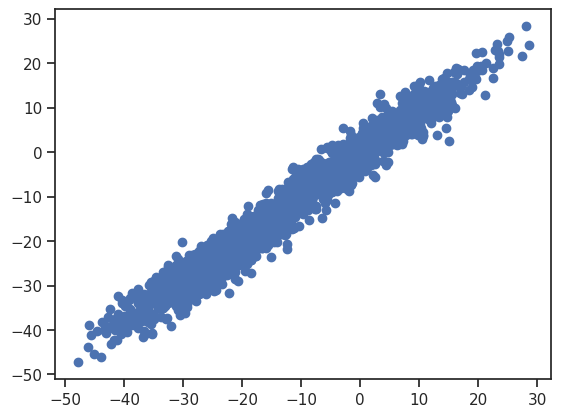

In [7]:
plt.scatter(y, y_pred)

Давайте теперь сравним нашу реализацию линейной регрессии с моделью из библиотеки `sklearn` - [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Сравним полученные результаты по метрике `mean_squared_error`

In [4]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [8]:
def mse(y_true, y_pred):
    return np.sum((y_true - y_pred)**2)/len(y_pred)

In [9]:
mse(y, y_pred), mean_squared_error(y, y_pred)

(np.float64(8.876023742805932), 8.876023742805932)

In [10]:
# fit sklearn LinReg and compute MSE
linreg = LinearRegression()

In [11]:
linreg.fit(X,y)
linreg_preds = linreg.predict(X)

In [12]:
mse(y, linreg_preds)

np.float64(8.876023742805932)

### Задача 2

Оцените долю объясненной дисперсии для вашей модели двумя способами:
1. С помощью [`sklearn.metrics.r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
2. Вручную, посчитав отношение объясненной дисперсии к полной.

Посчитайте explained variance также для истинных значений без шумовой компоненты (вам известны настоящие веса из `real_w`), взяв их в качестве предсказаний относительно `y`.

В каком из случаев дисперсия больше? Почему?

In [13]:
from sklearn.metrics import r2_score

In [18]:
def my_r2_score(y_true, y_pred):
  sse = np.sum((y_true - y_pred)**2)
  m = np.mean(y_true)
  var = np.sum((y_true - m)**2)

  return 1-sse/var

In [19]:
my_r2_score(y, y_pred), r2_score(y, y_pred)

(np.float64(0.9634550943301358), 0.9634550943301358)

## Задача 3.1

Давайте посмотрим, что произойдет, если мы работаем с данными с нелинейной зависимостью.

Попробуйте обучить на них линейную регреccию, визуализируйте предсказания, сделайте выводы о применимости линейной модели к этой задаче.

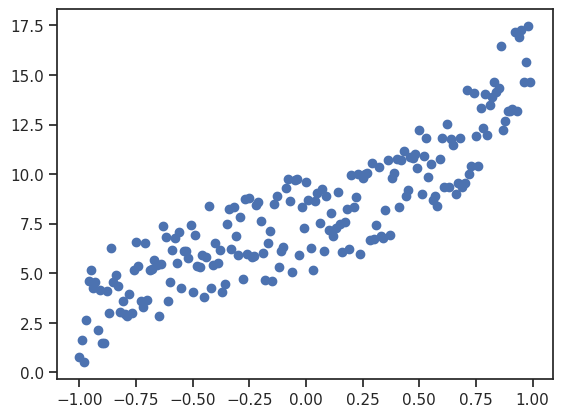

In [20]:
np.random.seed(777)
x = np.arange(-1, 1, 0.01)
y = 4 * x**3 + 2 * x**2 + x * 3 + 5 + np.random.rand(x.shape[0]) * 5
plt.scatter(x, y)
plt.show()

In [27]:
regressor  = AnalyticLinearRegression()
regressor.fit(x.reshape(-1,1), y)
y_pred = regressor.predict(x.reshape(-1,1))

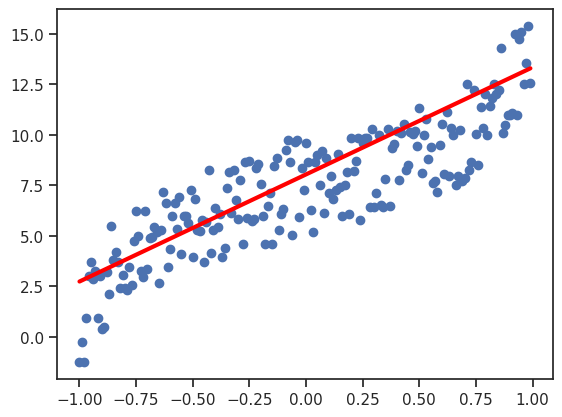

In [30]:
np.random.seed(777)
x = np.arange(-1,1,0.01)
y = 4 * x**3 * x**2 + x*3 + 5 +np.random.rand(x.shape[0]) * 5
plt.scatter(x,y)
plt.plot(x,y_pred, c = 'red', lw = 3)
plt.show()

## Задание 3.2
Значит ли полученный результат, что в данном случае линейная модель не применима? Над датасетом можно сделать некоторые преобразования, которые позволят линейной модели учить нелинейные зависимости.

Изучите документацию [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html), и с помощью нее сделайте предобработку данных.

Какой порядок полинома стоит взять? Переберите несколько разных вариантов

In [31]:
from sklearn.preprocessing import PolynomialFeatures

In [32]:
poly = PolynomialFeatures(3, include_bias =False)

In [33]:
x_poly = poly.fit_transform(x.reshape(-1,1))

In [34]:
x[:10]

array([-1.  , -0.99, -0.98, -0.97, -0.96, -0.95, -0.94, -0.93, -0.92,
       -0.91])

In [36]:
regressor  = AnalyticLinearRegression()
regressor.fit(x_poly,y)
y_pred = regressor.predict(x_poly)

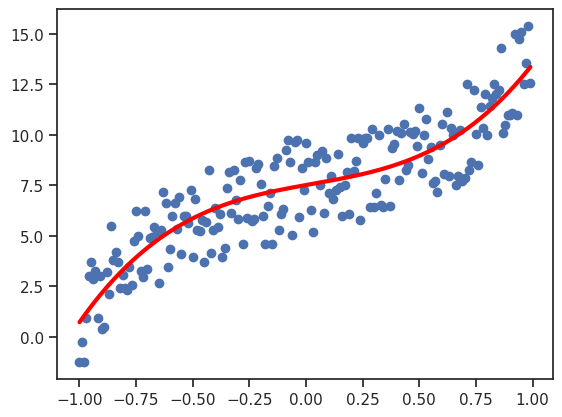

In [37]:
plt.scatter(x,y)
plt.plot(x,y_pred, c = 'red', lw = 3)
plt.show()

## Задание 3.3
Примените к данной задаче реализации линейной регрессии из sklearn: без регуляризации - `LinearRegression`, с L1 - `Lasso` и с L2 - `Ridge`.
Сравните коэффициенты полученных моделей, в каком случае больше всего нулевых коэффициентов?

In [38]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

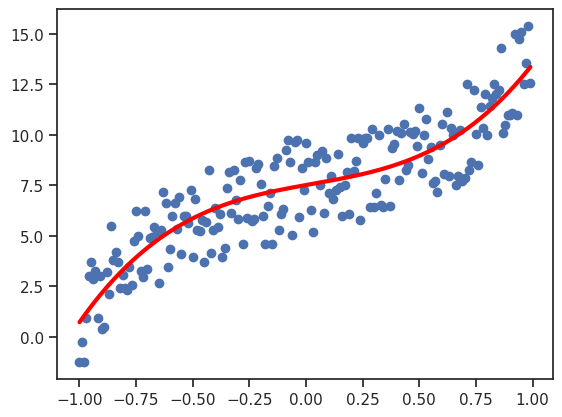

In [40]:
linreg = LinearRegression()
linreg.fit(x_poly,y)
linreg_preds = linreg.predict(x_poly)
plt.scatter(x,y)
plt.plot(x, linreg_preds, c='red', lw=3)
plt.show()

### Предобработка признаков

**Иногда признаки не сравнимы между собой** или вообще измеряются в разных величинах. Масштаб признаков непосредственно влияет на определение расстояния между объектами.

В Sklearn есть отдельный класс для стандартизации признаков в вашем датасете: [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

Он "запоминает" среднее и стандартное отклонение для каждого признака в вашем датасете (метод **fit**), после чего сможет стандартизировать с их помощью любую выборку такой размерности (метод **transform**).

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer(as_frame=True)
X = breast_cancer.data
y = breast_cancer.target

selection = X[["mean symmetry", "mean area"]].values

In [42]:
# create scaler object
scaler = StandardScaler()
# fit data to scaler
scaler.fit(selection)
# return transformed result
scaled_selection = scaler.transform(selection)

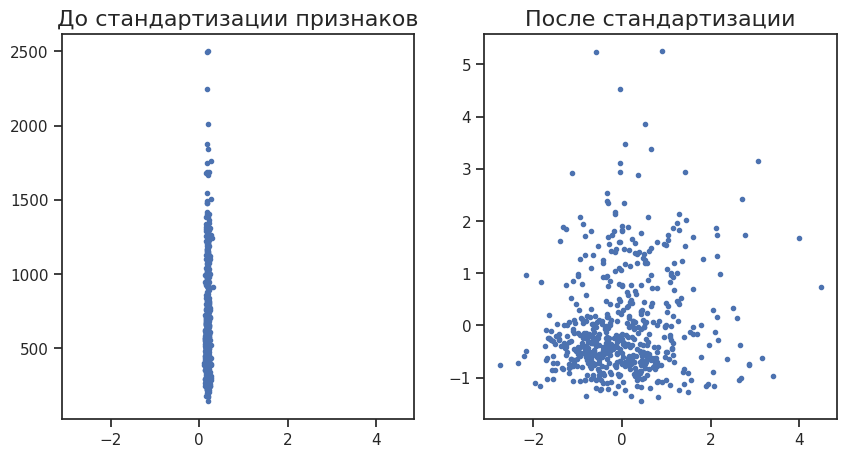

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(selection[:, 0], selection[:, 1], "b.")
axes[1].plot(scaled_selection[:, 0], scaled_selection[:, 1], "b.")
# set same x limits on left and right plots
axes[0].set_xlim(axes[1].get_xlim())
axes[0].set_title("До стандартизации признаков", size=16)
axes[1].set_title("После стандартизации", size=16);

## Задание 4.1

Возьмите эти 2 признака и попробуйте обучить на них модель логистической регрессии для задачи бинарной классификации.

Перед обучением разбейте датасет на 2 равные части для обучения и тестирования качества с использованием функции `train_test_split`

Попробуйте 2 варианта - со стандартизацией признаков, и без нее. Сравните качетсво полученных моделей по метрике F1. Есть ли отличия?

Посмотрите на значения полученных коэффициентов нормированных и не нормированных признаков? В каком случае значения коэффициентов говорят о важности соотвествующих признаков?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    selection, y, random_state=777, test_size=0.5
)

## Задание 4.2

А теперь попробуйте поварьировать параметр `max_iter` логистической регрессии, отвечающий за максимальное количество шагов градиентного спуска при минимизации функции ошибки.

Попробуйте разные варианты в диапазоне 10 - 100. Какая модель сходится быстрее, на стандартизированных признаках, или нет?

### Задача 5

Загрузите датасет BACE, расположенный по адресу:

`https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/knn/data/bace.csv`.

Вашей задачей будет научиться предсказывать связывание ингибиторов с белком β-секретазы 1 (идентификатор гена: [BACE](https://www.genecards.org/cgi-bin/carddisp.pl?gene=BACE1))

Предсказываемый класс записан в колонке `Class`. Обратите внимание, что переменная `pIC50` содержит отрицательный логарифм концентрации полумаксимального ингибирования $p\text{IC}_{50} = -\log_{10}(\text{IC}_{50})$ и способна полностью объяснить предсказываемый класс.

Колонки `mol` и `CID` не используйте. Колонка `Model` содержит разбиение на группы `Train`, `Valid`, `Test`. Постарайтесь получить наилучшее возможное качество на `Test` с помощью модели логистической регрессии. Используйте метрику F1-score.

1. Изучите документацию LogisticRegression из sklearn;
2. Попробуйте разные варианты регуляризации
3. Поварьируйте значение коэффициента регуляризации

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/knn/data/bace.csv -O bace.csv

In [ ]:
data = pd.read_csv("bace.csv")
X = data.iloc[:, 5:-1]
y = data["Class"]
group = data["Model"]

In [ ]:
X_train, y_train = X[group != "Test"], y[group != "Test"]
X_test, y_test = X[group == "Test"], y[group == "Test"]

## Задача 5.2
Используя полученную модель рассчитайте следующие метрики качества: Accuracy, Precision, Recall, F1, AUC, а также изобразите ROC-кривую.
Используйте реализации из `sklearn.metrics`


In [ ]:
from sklearn.metrics import (
    precision_score,
    roc_curve,
    roc_auc_score,
    accuracy_score,
)

In [ ]:
print(f"{acc=:.03f}")
print(f"{recall=:.03f}")
print(f"{precision=:.03f}")
print(f"{f1=:.03f}")

## Задача 5.3*
Напишите фукнцию, которая вычисляет вероятность того, что пара случайно выбранных объектов разных классов верно ранжирована моделью, т.е. предсказанная вероятность случайного выбранного объекта положительного класса, выше вероятности негативного класса.

Сравните со значением AUC.

In [ ]:
def estimate_rank_prob(y_true, probs, n_samples=100_000):

    return

In [ ]:
estimate_rank_prob(y_test, predicted_prob)